# Notebook 5: Failure Casebook

Cases are attempts that did not validate, infrastructure failures excluded. Export them first, from `Analysis/`:

    python -m analysis export-failures --results <experiment-results.csv> --db "<Output>/**/analysis.db" --logs <run>/logs --out data/failures --markdown

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.export_failure_cases import DEFAULT_SAMPLE_SEED, sample_cases
from analysis.normalize import build_paired_comparison
from analysis.plots import failure_category_bar, smell_type_breakdown
from analysis.schema import PRELIMINARY_FAILURE_LABELS

sns.set_theme(style='whitegrid')

DATA_DIR = Path(os.environ.get('ANALYSIS_DATA_DIR', '../../data'))
cases_path = DATA_DIR / 'failures' / 'failure_cases.csv'
if not cases_path.exists():
    raise FileNotFoundError(f'Missing {cases_path}; run `python -m analysis export-failures`.')
cases = pd.read_csv(cases_path, low_memory=False)

## Scope

In [2]:
display(cases.groupby('lane').agg(
    cases=('failure_case_id', 'size'),
    first_attempts=('is_first_attempt', 'sum'),
    chain_later_succeeded=('chain_succeeded', 'sum')))
display(cases['repo_name'].value_counts().rename('cases'))
display(cases.groupby(['lane', 'producer']).size().rename('cases').sort_values(ascending=False))

,cases,first_attempts,chain_later_succeeded
lane,,,
agentic,22,22,0
llm,20,9,10


repo_name
serilog-expressions     18
aspectcore-framework    17
gridify                  4
zstring                  3
Name: cases, dtype: int64

lane     producer                  
llm      gpt-oss-120b                  9
         GLM-5.3-thinking-high         5
         gpt-5.6-luna                  4
agentic  mini-swe-agent-custom-gpt     4
         mini-swe-agent-openai         4
llm      Kimi-K3-thinking-high         2
agentic  aider-custom-gpt              2
         aider-gemini                  2
         openhands-custom-gpt          2
         aider-custom-glm              1
         mini-swe-agent-custom-kimi    1
         copilot-custom-gpt            1
         copilot-anthropic             1
         aider-openai                  1
         mini-swe-agent-anthropic      1
         openhands-custom-kimi         1
         openhands-custom-glm          1
Name: cases, dtype: int64

## Preliminary labels

Rule-based starting points for open coding, not final categories.

outcome_classification,FailedEvidencePositive,NoChange,TimedOut,ValidationFailed,All
preliminary_failure_label,,,,,
build_failed,0,0,0,18,18
generation_failed,0,0,0,5,5
no_change,0,10,0,0,10
test_failed,5,0,0,3,8
timeout,0,0,1,0,1
All,5,10,1,26,42


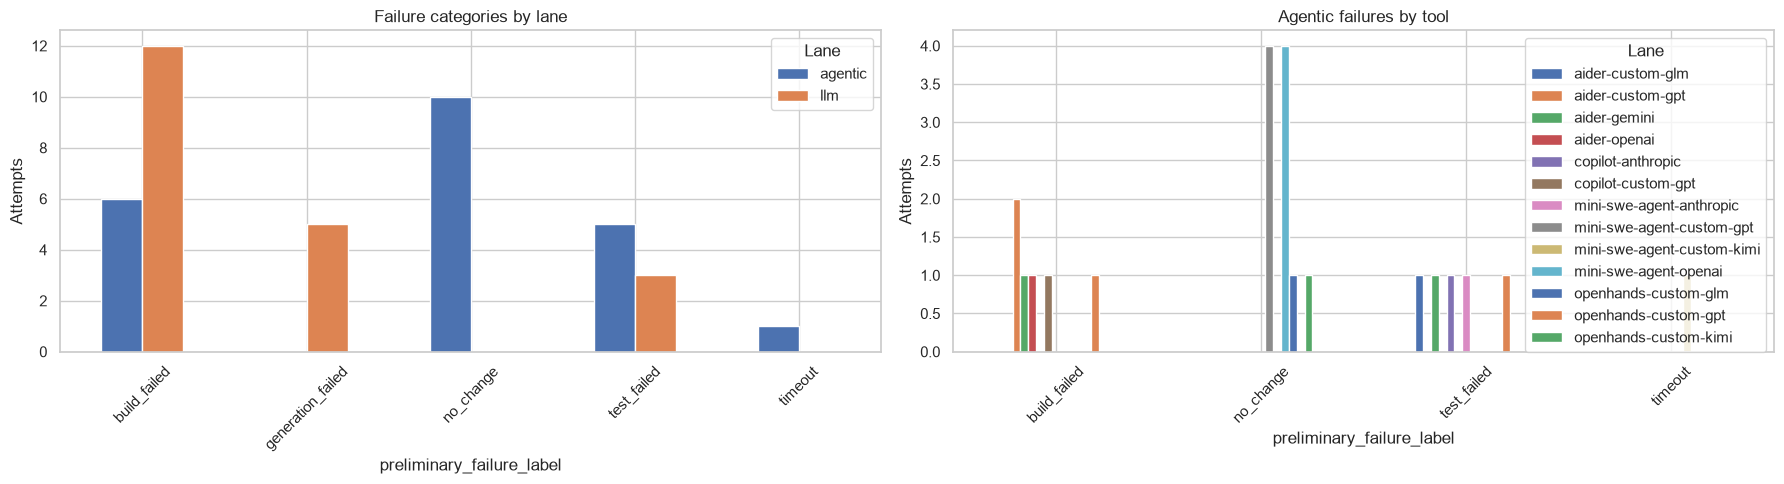

In [3]:
unexpected = set(cases['preliminary_failure_label']) - set(PRELIMINARY_FAILURE_LABELS)
if unexpected:
    print(f'Labels not in schema: {unexpected}')
display(pd.crosstab(cases['preliminary_failure_label'], cases['outcome_classification'], margins=True))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
failure_category_bar(cases, lane_col='lane', category_col='preliminary_failure_label', ax=axes[0])
failure_category_bar(cases[cases['lane'] == 'agentic'], lane_col='tool_id',
                     category_col='preliminary_failure_label', ax=axes[1])
axes[1].set_title('Agentic failures by tool')
plt.tight_layout()
plt.show()

## Stratified coding sample

In [4]:
stratified = sample_cases(cases, strategy='stratified-label', top_n=5, seed=DEFAULT_SAMPLE_SEED)
print(f'{len(stratified)} cases, up to 5 per label, seed {DEFAULT_SAMPLE_SEED}')
display(stratified[['failure_case_id', 'lane', 'producer', 'preliminary_failure_label', 'failure_summary']])

21 cases, up to 5 per label, seed 20260914


,failure_case_id,lane,producer,preliminary_failure_label,failure_summary
5,6,llm,GLM-5.3-thinking-high,build_failed,Docker build validation failed before test exe...
8,9,llm,gpt-oss-120b,generation_failed,The test method in the patch did not parse as ...
10,11,llm,gpt-oss-120b,build_failed,Docker build validation failed before test exe...
11,12,llm,gpt-oss-120b,build_failed,Docker build validation failed before test exe...
12,13,llm,gpt-oss-120b,build_failed,Docker build validation failed before test exe...
16,17,agentic,aider-gemini,test_failed,NaN
19,20,agentic,aider-custom-gpt,build_failed,NaN
21,22,agentic,mini-swe-agent-openai,no_change,NaN
23,24,agentic,mini-swe-agent-custom-gpt,no_change,NaN
24,25,agentic,mini-swe-agent-custom-gpt,no_change,NaN


## Headline-pair disagreements

Candidates where one side of a headline pair reached pass@1 VEP and the other did not, with the losing first attempt's failure case. A losing attempt that passed without moving the metrics has no case.

In [5]:
PAIRS = [('GLM-5.3-thinking-high', 'openhands-custom-glm'), ('gpt-5.6-luna', 'copilot-openai')]
OUTCOME = 'first_attempt_positive_impact'
chains = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv', low_memory=False)

rows = []
for llm_producer, tool in PAIRS:
    paired = build_paired_comparison(chains, llm_producer, tool, OUTCOME, llm_budget_mode='PassAt1')
    for r in paired[paired['winner'].isin(['llm_won', 'agentic_won'])].itertuples():
        rows.append({'candidate_key': r.candidate_key, 'pair': f'{llm_producer} vs {tool}',
                     'winner': r.winner, 'loser': tool if r.winner == 'llm_won' else llm_producer})
disagreements = pd.DataFrame(rows, columns=['candidate_key', 'pair', 'winner', 'loser'])
first = cases[cases['is_first_attempt'].astype(bool)
              & (cases['budget_mode'].eq('PassAt1') | cases['lane'].eq('agentic'))]
display(disagreements.merge(first, left_on=['candidate_key', 'loser'],
                            right_on=['candidate_key', 'producer'], how='left')
        [['pair', 'winner', 'loser', 'failure_case_id', 'preliminary_failure_label', 'failure_summary']])

,pair,winner,loser,failure_case_id,preliminary_failure_label,failure_summary
0,GLM-5.3-thinking-high vs openhands-custom-glm,agentic_won,GLM-5.3-thinking-high,5,build_failed,Docker build validation failed before test exe...
1,GLM-5.3-thinking-high vs openhands-custom-glm,agentic_won,GLM-5.3-thinking-high,6,build_failed,Docker build validation failed before test exe...
2,gpt-5.6-luna vs copilot-openai,agentic_won,gpt-5.6-luna,1,build_failed,Docker build validation failed before test exe...


## Safety failures

Production code, project files or overbroad changes.

In [6]:
display(sample_cases(cases, strategy='high-severity')
        [['failure_case_id', 'lane', 'producer', 'preliminary_failure_label', 'source_method_name',
          'failure_summary']])

,failure_case_id,lane,producer,preliminary_failure_label,source_method_name,failure_summary


## Case files

In [7]:
case_dirs = sorted((DATA_DIR / 'failures' / 'cases').glob('case_*'))
files = pd.Series([f.name for d in case_dirs for f in d.iterdir()], dtype=str)
# Tool logs are named per tool family; collapse them to one row each.
print(files.str.replace(r'^[\w.-]+\.(events\.jsonl|stderr\.log)$', r'<tool>.\1', regex=True)
      .value_counts().rename(f'files across {len(case_dirs)} cases').to_string())
if case_dirs:
    print('\n' + (case_dirs[0] / 'case.md').read_text(encoding='utf-8')[:900])

case.md                   42
existing_test_class.cs    42
prompt.md                 42
source_class.cs           42
test_run.log              31
changed-files.txt         22
<tool>.stderr.log         22
patch.diff                22
modified_file.cs          15
generated_test.json        9
<tool>.events.jsonl        6

# Failure Case 1

**Repo:** serilog/serilog-expressions
**Commit:** 697c8fa89ec1
**Lane:** llm
**Producer:** gpt-5.6-luna
**Model:** gpt-5.6-luna
**Attempt:** 1 (first attempt: True; chain later succeeded: False)
**Source method:** `ToString`
**Signature:** `public override string ToString()`
**Source file:** `D:\Projects\TestMap\Temp\serilog\serilog-expressions\697c8fa89ec167b1f3f9457c8cee500ad02e8bc2\src\Serilog.Expressions\Expressions\Ast\ConstantExpression.cs`
**Failure label:** `build_failed`
**Outcome:** `ValidationFailed`
**Failure kind:** `Compilation`
**Failure stage:** `build`

## Failure Summary

Docker build validation failed before test execution.

## Artifac

## Generated-test smells: failed versus validated attempts

count  mean  median
lane    result                        
agentic failed         9  1.50    1.17
        validated     74  1.48    1.52
llm     failed        20  1.65    2.00
        validated     34  1.65    2.00

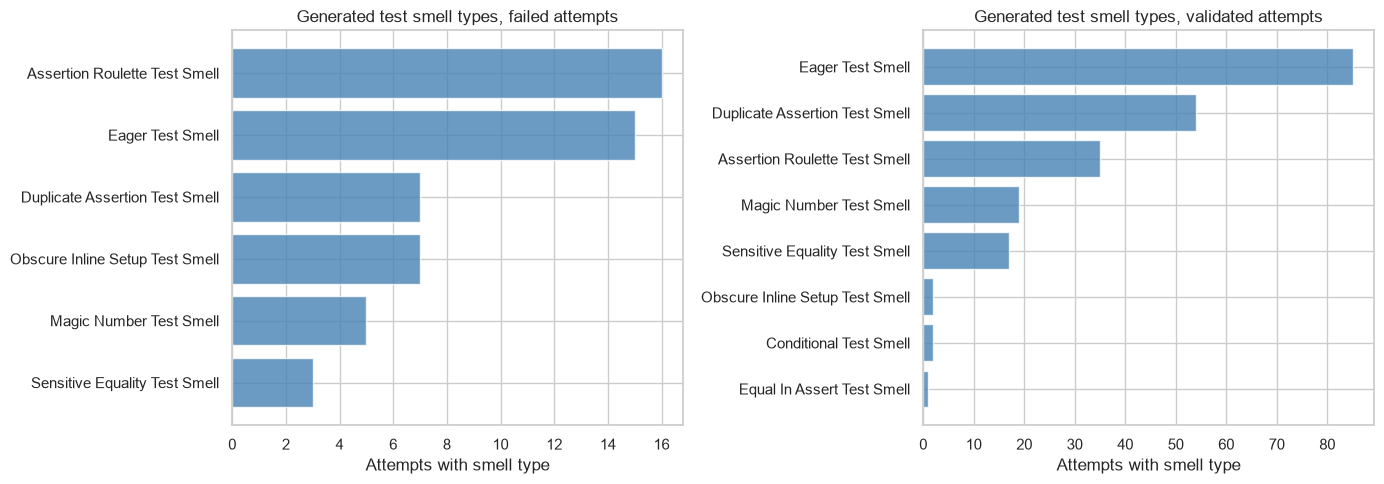

In [8]:
att = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv', low_memory=False)
att = att[~att['infrastructure_failure'].astype(bool) & (att['generated_test_count'].fillna(0) > 0)].copy()
att['smells_per_test'] = att['generated_test_smell_count'] / att['generated_test_count']
att['result'] = att['validated_success'].map({True: 'validated', False: 'failed'})
display(att.groupby(['lane', 'result'])['smells_per_test'].agg(['count', 'mean', 'median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, result in zip(axes, ['failed', 'validated']):
    smell_type_breakdown(att[att['result'] == result], 'generated_test_smell_types', ax=ax)
    ax.set_title(f'Generated test smell types, {result} attempts')
plt.tight_layout()
plt.show()